# ML-01 · Unduh dan Bersihkan Korpus IDNHoaxCorpus

**Proyek:** HoaxScan, bagian Machine Learning
**Tujuan:** menghasilkan data bersih `train.csv` dan `test.csv` (kolom `text`, `label`) untuk ML-02 (IndoBERT) dan ML-03 (baseline).

**Sumber data:** [github.com/9uz/IDNHoaxCorpus](https://github.com/9uz/IDNHoaxCorpus), lisensi MIT. Berisi tweet dari X (Twitter) yang dikumpulkan Universitas Muhammadiyah Ponorogo pada 2020.

**Label akhir:** `1` = hoax, `0` = valid. Label `?` tidak dipakai untuk training, tetapi disimpan terpisah.

## 0. Persiapan
Memasang library yang belum tersedia. Di Google Colab biasanya hanya `wordcloud` yang perlu dipasang; sel ini aman dijalankan berulang kali.

In [1]:
import sys, subprocess, importlib.util

REQUIRED = {"pandas": "pandas", "sklearn": "scikit-learn", "matplotlib": "matplotlib", "wordcloud": "wordcloud"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Memasang:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

IN_COLAB = "google.colab" in sys.modules
print("Berjalan di Google Colab" if IN_COLAB else "Berjalan di komputer lokal")
print("Semua library siap.")

Berjalan di komputer lokal
Semua library siap.


## 1. Unduh dataset

In [2]:
import os, re, subprocess
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
REPO_DIR = "IDNHoaxCorpus"
RAW_PATH = os.path.join(REPO_DIR, "dataset", "datasetUMPOHoax.csv")
OUT_DIR = os.path.join("data", "processed")

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "-q", "https://github.com/9uz/IDNHoaxCorpus.git"], check=True)

os.makedirs(OUT_DIR, exist_ok=True)
pd.set_option("display.max_colwidth", 160)

raw = pd.read_csv(RAW_PATH)
print("Ukuran:", raw.shape)
print("Kolom :", raw.columns.tolist())

Ukuran: (4617, 6)
Kolom : ['topik', 'keyword', 'tweet', 'gambar', 'url', 'label']


## 2. Eksplorasi data
Eksplorasi difokuskan pada hal yang berpengaruh ke model teks: sebaran label, contoh isi tweet, panjang tweet, "gangguan" khas Twitter, dan kata-kata yang bisa membocorkan label.

### 2.1 Sebaran label

In [3]:
label_dist = pd.DataFrame({
    "Jumlah": raw["label"].value_counts(),
    "Persen": (raw["label"].value_counts(normalize=True) * 100).round(1),
})
label_dist

,Jumlah,Persen
label,,
hoax,3042,65.9
?,845,18.3
valid,730,15.8


### 2.2 Contoh tweet per label

In [4]:
for lbl in ["hoax", "valid", "?"]:
    print(f"=== {lbl} ===")
    for t in raw.loc[raw["label"] == lbl, "tweet"].dropna().sample(4, random_state=RANDOM_STATE):
        print("-", t[:200])
    print()

=== hoax ===
- Ngeliat harimau yang endut gitu, jadi keinget tweet tentang kebun binatang di indonesia yang mulai gak bisa kasih makan satwa nya. Harimaunya kurus banget, krempeng sampe keliatan bentuk tulangnya
- Dampak 2jam keciplak kecipluk di kolam brhasil meningkatkan gairah makan yg luar biasa, sate ayam ☑ tempe mendoan ☑ ayam goreng mentega ☑
- Viral!!! Mohon Sebarkan Garam Mengandung Pecahan Kaca: http://youtu.be/iUbcv2-nT1s?a melalui
- Pake aja kalung mengkudu, terhindar dari penyakit gondong. Btw, ini serius lo

=== valid ===
- Penjelasan Badan POM RI terkait Luwak White Koffie yang dicurigai mengandung DNA Babi.
- Beberapa tabir surya diformulasikan khusus untuk wajah untuk melindungi kulit Anda dari sinar UV berbahaya yang dapat menyebabkan kulit terbakar, penuaan dini, dan kanker kulit. #TempoCantika
- Malam kretekus dan seluruh masyarakat Indonesia... Masih ada aja loh yg hembusin isu bahwa filter rokok mengandung darah babi. Padahal sudah jelas isu tersebut adalah HOAX. 

### 2.3 Tweet kosong dan duplikat

In [5]:
print("Tweet kosong        :", raw["tweet"].isna().sum())
print("Tweet duplikat persis:", raw["tweet"].dropna().duplicated().sum())

Tweet kosong        : 18
Tweet duplikat persis: 59


### 2.4 Gangguan khas Twitter per label
**Gangguan** = bagian tweet yang bukan isi klaimnya: link, mention, hashtag, tag media, tanda terpotong, dan sejenisnya.

**Kenapa dicek?** Model belajar dari pola apa saja yang membedakan label, termasuk pola yang tidak ada hubungannya dengan benar-salahnya isi. Kalau sebuah gangguan jauh lebih sering muncul di satu label, model bisa mengambil jalan pintas:

> "Ada tanda `...` → kemungkinan hoax", atau "Ada tag `[Detiknews]` → kemungkinan valid".

Skornya terlihat bagus di dataset ini, tetapi gagal saat menilai berita sungguhan, karena di dunia nyata tanda `...` atau nama media tidak menentukan benar-tidaknya isi. Bagian ini dipakai untuk **memutuskan gangguan mana yang wajib dihapus** di langkah 4.

In [6]:
patterns = {
    "URL": r"https?://|www\.",
    "@mention": r"@\w+",
    "#hashtag": r"#\w+",
    "RT": r"\bRT\b",
    "Tag media di awal, mis. [Detiknews]": r"^\s*\[[^\]]+\]",
    "Terpotong (... atau …)": r"\.\.\.|…",
    "Kata 'hoax/hoaks'": r"\bhoa(?:x|ks)\b",
}
tw = raw["tweet"].fillna("")
noise = pd.DataFrame({
    name: tw.str.contains(p, case=False, regex=True).groupby(raw["label"]).mean().mul(100).round(1)
    for name, p in patterns.items()
}).T
noise = noise[["hoax", "valid"]]
noise["Selisih (poin %)"] = (noise["hoax"] - noise["valid"]).round(1)
noise = noise.sort_values("Selisih (poin %)", key=abs, ascending=False)
noise.columns = ["% di hoax", "% di valid", "Selisih (poin %)"]
noise

,% di hoax,% di valid,Selisih (poin %)
Terpotong (... atau …),20.4,10.0,10.4
#hashtag,14.7,24.8,-10.1
Kata 'hoax/hoaks',2.0,9.9,-7.9
URL,35.8,29.3,6.5
"Tag media di awal, mis. [Detiknews]",1.0,6.3,-5.3
RT,2.4,1.1,1.3
@mention,7.7,8.5,-0.8


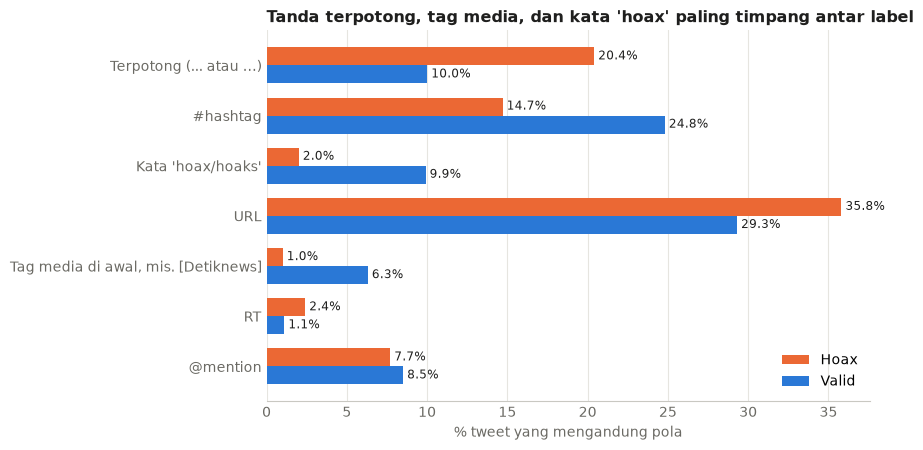

In [7]:
import matplotlib.pyplot as plt
import numpy as np

HOAX_COLOR, VALID_COLOR = "#eb6834", "#2a78d6"
INK, MUTED = "#1f1f1e", "#6b6a64"

plot_df = noise.iloc[::-1]  # selisih terbesar di atas
y = np.arange(len(plot_df))
h = 0.36

fig, ax = plt.subplots(figsize=(9, 4.6))
b1 = ax.barh(y + h / 2, plot_df["% di hoax"], height=h, color=HOAX_COLOR, label="Hoax")
b2 = ax.barh(y - h / 2, plot_df["% di valid"], height=h, color=VALID_COLOR, label="Valid")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8.5, color=INK)

ax.set_yticks(y, plot_df.index, color=INK)
ax.set_xlabel("% tweet yang mengandung pola", color=MUTED)
ax.set_title("Tanda terpotong, tag media, dan kata 'hoax' paling timpang antar label",
             loc="left", fontsize=11.5, color=INK, fontweight="bold")
ax.grid(axis="x", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#c9c8c2")
ax.tick_params(colors=MUTED, length=0)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

**Cara membaca:** semakin jauh jarak batang oranye (hoax) dan biru (valid) pada satu pola, semakin besar risiko model memakai pola itu sebagai jalan pintas.

| Pola | Keputusan | Alasan |
|---|---|---|
| Terpotong `...` | Dihapus | Bekas cara pengambilan data (tweet panjang dipotong), bukan isi |
| Tag media `[Detiknews]` | Dihapus | Nama sumber, bukan isi klaim |
| URL, @mention, RT | Dihapus | Tidak mengandung isi klaim |
| #hashtag | Tanda `#` dihapus, katanya disimpan | Kata di dalam hashtag kadang bermakna (`#vaksin` → `vaksin`) |
| Kata "hoax/hoaks" | Dibiarkan, dicatat sebagai limitasi | Bagian dari kalimat ("isu ini HOAX"), menghapusnya bisa mengubah makna |

### 2.5 Kata yang paling sering muncul per label

In [8]:
STOPWORDS = set("""yang dan di ke dari ini itu untuk dengan pada adalah atau juga tidak ada akan bisa
dalam karena jadi kalau sudah saja lebih kita kamu aku saya nya ya yg dgn utk gak ga aja
tak bagi oleh sebagai para mereka rt amp http https co
dapat banyak bahwa tapi semua apa mau jika buat bikin sama lagi dia udah hingga tersebut saat via
seperti sangat hanya bukan baru tau tdk pake jangan menjadi membuat""".split())

def top_words(texts, n=15):
    c = Counter()
    for t in texts:
        c.update(w for w in re.findall(r"[a-z]{3,}", re.sub(r"http\S+", " ", str(t).lower())) if w not in STOPWORDS)
    return [f"{w} ({k})" for w, k in c.most_common(n)]

pd.DataFrame({lbl: top_words(raw.loc[raw["label"] == lbl, "tweet"].dropna()) for lbl in ["hoax", "valid"]})

,hoax,valid
0,makan (285),manfaat (216)
1,air (272),kesehatan (108)
2,covid (266),air (81)
3,vaksin (259),covid (81)
4,mengandung (242),salah (70)
5,menyebabkan (217),buah (67)
6,berbahaya (214),tubuh (60)
7,kanker (212),makan (57)
8,manfaat (188),mengandung (56)
9,virus (180),hoax (55)


**Word cloud** di bawah menampilkan kata yang sama secara visual: semakin besar tulisannya, semakin sering kata itu muncul di label tersebut.

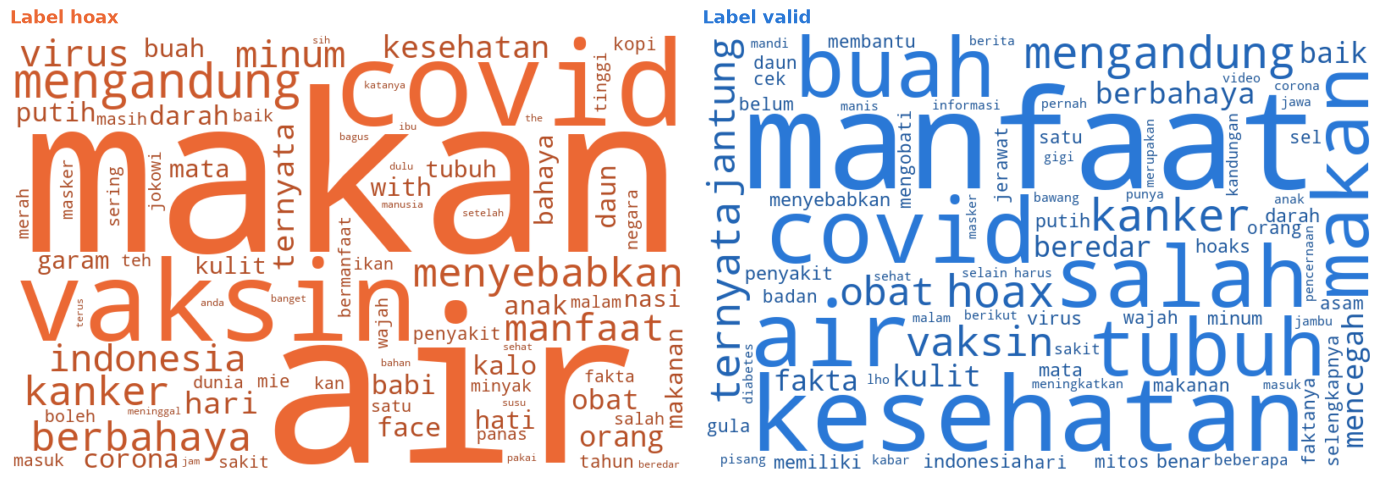

In [9]:
from wordcloud import WordCloud
import matplotlib.colors as mcolors

def word_freq(texts):
    c = Counter()
    for t in texts:
        c.update(w for w in re.findall(r"[a-z]{3,}", re.sub(r"http\S+", " ", str(t).lower())) if w not in STOPWORDS)
    return c

def one_hue(hex_color):
    # semua kata memakai satu warna label, dengan sedikit variasi gelap-terang
    r, g, b = mcolors.to_rgb(hex_color)
    def color_func(word, font_size, position, orientation, random_state=None, **kw):
        k = 0.65 + 0.35 * min(font_size / 90, 1)
        return f"rgb({int(r * 255 * k)}, {int(g * 255 * k)}, {int(b * 255 * k)})"
    return color_func

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, lbl, color in [(axes[0], "hoax", HOAX_COLOR), (axes[1], "valid", VALID_COLOR)]:
    freq = word_freq(raw.loc[raw["label"] == lbl, "tweet"].dropna())
    wc = WordCloud(width=800, height=520, background_color="white", max_words=80,
                   color_func=one_hue(color), random_state=RANDOM_STATE, prefer_horizontal=0.95,
                   margin=6, min_font_size=11)
    ax.imshow(wc.generate_from_frequencies(freq), interpolation="bilinear")
    ax.set_title(f"Label {lbl}", loc="left", fontsize=13, fontweight="bold", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Yang terlihat:**
- **Hoax** didominasi kata bernada menakutkan atau klaim kesehatan: *berbahaya, kanker, menyebabkan, mengandung, covid, vaksin, virus*.
- **Valid** didominasi kata informatif: *manfaat, kesehatan, tubuh, buah*, dan juga kata bantahan seperti *salah, hoax, ternyata*. Ini karena tweet yang membantah hoax ("isu itu HOAX") diberi label valid.
- Kedua label sama-sama banyak membahas *air, makan, covid*, sehingga model tidak bisa hanya mengandalkan topik; ia harus memahami cara klaimnya disampaikan.

### 2.6 Topik terbanyak

In [10]:
print("Jumlah topik unik:", raw["topik"].str.strip().str.lower().nunique())
raw["topik"].str.strip().str.lower().value_counts().head(10)

Jumlah topik unik: 511


topik
vaksin          93
garam           54
kopi            33
bawang putih    30
dana haji       28
nasi            24
kangkung        21
mandi           21
kacang          21
manfaat         21
Name: count, dtype: int64

### Temuan eksplorasi
| Temuan | Angka | Dampak ke langkah berikutnya |
|---|---|---|
| Label tidak seimbang | hoax 65,9%, `?` 18,3%, valid 15,8% | Label `?` dibuang. Sisanya sekitar 80% hoax, jadi ML-02 perlu class weight |
| Tweet kosong dan duplikat | 18 kosong, 59 duplikat persis | Dibuang. Duplikat dicek ulang setelah teks dibersihkan |
| Tag media di awal (`[Detiknews]`) | 6,3% di valid vs 1,0% di hoax | **Dihapus**, supaya model tidak menebak dari nama media |
| Tanda terpotong `...` | 20,4% di hoax vs 10,0% di valid | **Dihapus**, karena ini jejak cara pengambilan data, bukan isi |
| Hashtag | 24,8% di valid vs 14,7% di hoax | Tanda `#` dihapus, kata di dalamnya tetap disimpan |
| Kata "hoax/hoaks" | 9,9% di valid vs 2,0% di hoax | Tweet bantahan ("isu ini HOAX") diberi label valid. Dibiarkan, karena itu memang isi tweet, tapi dicatat sebagai limitasi |
| Kata dominan | hoax: *makan, covid, vaksin, berbahaya, kanker*; valid: *manfaat, kesehatan, salah, hoax* | Topik didominasi kesehatan dan COVID-19, bukan politik |
| Topik | 511 topik unik, terbanyak *vaksin* (93) dan *garam* (54) | Model mungkin kurang akurat untuk topik di luar kesehatan |

## 3. Rapikan label
Hanya `hoax` dan `valid` yang dipakai. Baris berlabel `?` disimpan terpisah (`unlabeled.csv`).

In [11]:
steps = []  # catatan jumlah baris per langkah
df = raw.copy()
steps.append(("Data mentah", len(df)))

df["label"] = df["label"].astype(str).str.strip().str.lower()
unlabeled = df[~df["label"].isin(["hoax", "valid"])].copy()
df = df[df["label"].isin(["hoax", "valid"])].copy()
df["label"] = (df["label"] == "hoax").astype(int)  # 1 = hoax, 0 = valid
steps.append(("Buang label '?'", len(df)))

df = df[df["tweet"].notna()]
steps.append(("Buang tweet kosong (NaN)", len(df)))
df["label"].value_counts()

label
1    3041
0     716
Name: count, dtype: int64

## 4. Bersihkan teks
- Hapus **semua URL dan nama domain**. Kolom `url` (link tweet) juga tidak dipakai sebagai input.
- Hapus `RT`, `@mention`, dan tanda `#` (kata di dalam hashtag tetap disimpan).
- Hapus tag media di awal tweet (misalnya `[Detiknews]`), karena di eksplorasi jauh lebih sering muncul di tweet valid.
- Hapus tanda terpotong `...` / `…` dan karakter rusak, karena lebih sering muncul di tweet hoax.
- Rapikan kurung kosong, entitas HTML, dan spasi.

In [12]:
URL_RE = re.compile(r"https?://\S+|www\.\S+|pic\.twitter\.com/\S+|\b\S+\.(?:com|co\.id|id|co|net|org|ly)\b\S*", re.I)

def clean(text):
    t = str(text)
    t = URL_RE.sub(" ", t)
    t = re.sub(r"\bRT\b", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = t.replace("#", " ")
    t = t.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    t = re.sub(r"^\s*\[[^\]]{1,30}\]", " ", t)    # tag media di awal
    t = re.sub(r"\.{3,}|…|\ufffd", " ", t)            # tanda terpotong & karakter rusak
    t = re.sub(r"\(\s*\)|\[\s*\]", " ", t)        # kurung kosong
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text"] = df["tweet"].apply(clean)
df[["tweet", "text"]].head(8)

,tweet,text
0,Mahasiswa ITS buat pembangkit listrik dari kolam air garam. Gimana sob? Satu lagi penemuan sumber energi alternatif. http://ow.ly/i/2X2RP,Mahasiswa ITS buat pembangkit listrik dari kolam air garam. Gimana sob? Satu lagi penemuan sumber energi alternatif.
1,Lampu Dengan Sumber Energi Air Garam Ini Berpotensi Dijadikan Charger Smartphone: Sumber energi alternatif tam... http://bit.ly/1SHw8X0,Lampu Dengan Sumber Energi Air Garam Ini Berpotensi Dijadikan Charger Smartphone: Sumber energi alternatif tam
2,#didUknow Lampu LED yang menggunakan air dan garam sebagai sumber listrik: Belakangan banyak energi... http://d-id.tk/PovJ8e (@keripiku),didUknow Lampu LED yang menggunakan air dan garam sebagai sumber listrik: Belakangan banyak energi
3,#tekno Lampu Dengan Sumber Energi Air Garam Ini Berpotensi Dijadikan Charger Smartphone http://goo.gl/waWW4H,tekno Lampu Dengan Sumber Energi Air Garam Ini Berpotensi Dijadikan Charger Smartphone
4,"Green House,lampu darurat dg sumber energi garam&air.ada port USB yg dpt digunakan Hiseners utk mengisi baterai hp.","Green House,lampu darurat dg sumber energi garam&air.ada port USB yg dpt digunakan Hiseners utk mengisi baterai hp."
7,"[Detiknews] Di Kampus Lain Ratusan Juta, Biaya Masuk FK Unsoed Rp 0!: Jika FK Undip mematok uang pangkal Rp 125 ... http://bit.ly/LZGNrw","Di Kampus Lain Ratusan Juta, Biaya Masuk FK Unsoed Rp 0!: Jika FK Undip mematok uang pangkal Rp 125"
8,"Ini pencemaran nama baik, gk masuk akal kl masuk PT Undip ampe ngeluarin uang 87 M buat uang pangkal, 87 M itu besar banget,,!","Ini pencemaran nama baik, gk masuk akal kl masuk PT Undip ampe ngeluarin uang 87 M buat uang pangkal, 87 M itu besar banget,,!"
9,"Di Kampus Lain Ratusan Juta, Biaya Masuk FK Unsoed Rp 0!: Jika FK Undip mematok uang pangkal Rp 125 juta, maka d... http://bit.ly/LZGNrw","Di Kampus Lain Ratusan Juta, Biaya Masuk FK Unsoed Rp 0!: Jika FK Undip mematok uang pangkal Rp 125 juta, maka d"


## 5. Buang teks kosong dan duplikat
Tweet pendek **tidak dibuang**, karena pendeknya bisa jadi akibat pembersihan (URL, mention, dan tag sudah dihapus), bukan karena isinya tidak berguna. Yang dibuang hanya teks yang **benar-benar kosong** setelah dibersihkan (misalnya tweet yang isinya hanya link).

Contoh tweet yang menjadi pendek (≤ 3 kata) setelah dibersihkan:

In [13]:
short = df[df["text"].str.split().str.len().between(1, 3)]
print("Jumlah tweet ≤ 3 kata setelah dibersihkan:", len(short))
short[["tweet", "text", "label"]].head(10)

Jumlah tweet ≤ 3 kata setelah dibersihkan: 13


,tweet,text,label
64,[cm] kenapa ini guysss??,kenapa ini guysss??,1
207,KANGKUNG MENGANDUNG LINTAH??? http://fb.me/29E0y7SSC,KANGKUNG MENGANDUNG LINTAH???,1
394,Gajah berkaki lima https://instagram.com/p/Bq4T4PhFtPi/?utm_source=ig_twitter_share&igshid=lyjq23u7kj5e,Gajah berkaki lima,1
990,Bumi datar,Bumi datar,1
992,Konspirasi bumi datar,Konspirasi bumi datar,1
1040,Gajah berkaki lima https://instagram.com/p/Bq4T4PhFtPi/?utm_source=ig_twitter_share&igshid=lyjq23u7kj5e,Gajah berkaki lima,1
1788,Manfaat Yakult http://mrsupel.blogspot.com/2012/10/manfaat-yakult.html?m=1,Manfaat Yakult,1
2328,Pesona Mahameru http://192.168.0.105:8000/artikel/manfaat-dari-daun-pegagan-atau-centella-asiatica-untuk-kecantikan,Pesona Mahameru,1
3363,"Asam urat,,pake emping","Asam urat,,pake emping",1
3365,asam urat emping,asam urat emping,1


In [14]:
df = df[df["text"].str.len() > 0]
steps.append(("Buang teks kosong setelah dibersihkan", len(df)))

df["_key"] = df["text"].str.lower()
conflict = df.groupby("_key")["label"].nunique()
conflict_keys = conflict[conflict > 1].index
print("Teks sama dengan label berbeda:", len(conflict_keys))
df = df[~df["_key"].isin(conflict_keys)]
steps.append(("Buang teks dengan label bertentangan", len(df)))

df = df.drop_duplicates(subset="_key").drop(columns="_key")
steps.append(("Buang duplikat", len(df)))
df["label"].value_counts()

Teks sama dengan label berbeda: 6


label
1    2923
0     704
Name: count, dtype: int64

## 6. Bagi data 80 / 20 (stratified)
- **train (80%)**: data yang dipelajari model.
- **test (20%)**: data yang tidak pernah dilihat model, hanya dipakai di akhir (ML-04) untuk menilai performa.

`stratify` membuat perbandingan hoax dan valid sama di kedua bagian. Data **tidak diseimbangkan** di sini; penyeimbangan dilakukan di ML-02 dan hanya pada data train.

In [15]:
data = df[["text", "label", "topik"]].reset_index(drop=True)
train, test = train_test_split(data, test_size=0.20, stratify=data["label"], random_state=RANDOM_STATE)

for f in os.listdir(OUT_DIR):  # hapus hasil lama
    os.remove(os.path.join(OUT_DIR, f))
train[["text", "label"]].to_csv(os.path.join(OUT_DIR, "train.csv"), index=False)
test[["text", "label"]].to_csv(os.path.join(OUT_DIR, "test.csv"), index=False)
unlabeled[["topik", "tweet"]].to_csv(os.path.join(OUT_DIR, "unlabeled.csv"), index=False)

## 7. Ringkasan untuk laporan

In [16]:
summary_steps = pd.DataFrame(steps, columns=["Langkah", "Sisa baris"])
summary_steps["Dibuang"] = (-summary_steps["Sisa baris"].diff()).fillna(0).astype(int)
summary_steps

,Langkah,Sisa baris,Dibuang
0,Data mentah,4617,0
1,Buang label '?',3772,845
2,Buang tweet kosong (NaN),3757,15
3,Buang teks kosong setelah dibersihkan,3754,3
4,Buang teks dengan label bertentangan,3740,14
5,Buang duplikat,3627,113


In [17]:
rows = []
for name, d in [("train", train), ("test", test)]:
    rows.append({"Split": name, "Total": len(d),
                 "Hoax (1)": int((d["label"] == 1).sum()),
                 "Valid (0)": int((d["label"] == 0).sum()),
                 "% Hoax": round(100 * d["label"].mean(), 1)})
summary_split = pd.DataFrame(rows)
summary_split.to_csv(os.path.join(OUT_DIR, "summary_split.csv"), index=False)
summary_split

,Split,Total,Hoax (1),Valid (0),% Hoax
0,train,2901,2338,563,80.6
1,test,726,585,141,80.6


In [18]:
print("Hasil akhir train.csv:")
pd.read_csv(os.path.join(OUT_DIR, "train.csv")).head()

Hasil akhir train.csv:


,text,label
0,Pekan ini hoaks terkait vaksin Sinovac yang berbahaya karena virus mati bisa hidup lagi beredar. Lalu seperti apa faktanya? Simak penjelasan lengkapnya beri...,0
1,"aku baru tau klo masako mengandung babi. Jadi selama ini orang tua babi adalah masako. :|""",1
2,"Coklat dan kacang bisa menyebabkan jerawat, mitos atau fakta? CLICK: buat cari tau yang sebenarnya! HJGenerik HexpharmJaya HarusJeli InfoKesehatan HariPersa...",1
3,"Buah dan sayuran non-organik mengandung residu bahan kimia dari pestisida. Karena itu, sebelum dikonsumsi har",1
4,"Mata Jenazah Pasien COVID-19 Diambil Diam-diam, Cek Faktanya cekfakta",1


## 8. Catatan
- Dataset berisi **tweet**, bukan artikel berita, sehingga gaya bahasanya berbeda dengan teks yang akan dinilai HoaxScan.
- Kelas tidak seimbang (sekitar 80% hoax). Gunakan class weight di ML-02 dan nilai model dari F1 / recall per kelas, bukan hanya akurasi.
- Untuk memilih checkpoint (ML-02) dan threshold (ML-06), ambil sebagian kecil dari **train** sebagai data validasi. Data test tetap tidak disentuh sampai ML-04.

## 9. Simpan hasil
File di Google Colab **hilang saat runtime dimatikan**. Sel ini membungkus folder `data/processed` menjadi `processed_data.zip`, lalu:
- di **Colab**: otomatis mengunduhnya ke komputer (izinkan pop-up unduhan bila diminta);
- di **komputer lokal**: zip disimpan di folder yang sama dengan notebook.

In [19]:
import shutil

zip_path = shutil.make_archive("processed_data", "zip", OUT_DIR)
print("Isi zip:", sorted(os.listdir(OUT_DIR)))
print("Tersimpan:", os.path.abspath(zip_path))

if IN_COLAB:
    from google.colab import files
    files.download(zip_path)

Isi zip: ['summary_split.csv', 'test.csv', 'train.csv', 'unlabeled.csv']
Tersimpan: D:\smt5\lingkungan\processed_data.zip
